In [10]:
import os
import sys
import pandas as pd
import numpy as np
import missingno
import csv

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)

from utils import *

In [11]:
import os
import sys
import pandas as pd
import numpy as np
import missingno
import csv

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)

from utils import *

In [12]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [13]:
base_path = f'../../data/{NUTS2}/results/'

In [14]:
file_list = os.listdir(base_path)
file_list.sort()
file_list

['GR_Thessaly_Results_2010-2022.csv',
 'GR_Thessaly_Results_2023-August-1st.csv',
 'GR_Thessaly_Results_2023-August-1st_(new).csv',
 'GR_Thessaly_Results_2023-July-1st.csv',
 'GR_Thessaly_Results_2023-July-1st_(new).csv',
 'GR_Thessaly_Results_2023-July-2nd.csv',
 'GR_Thessaly_Results_2023-July-2nd_(new).csv',
 'GR_Thessaly_Results_2023-June-1st.csv',
 'GR_Thessaly_Results_2023-June-1st_(new).csv',
 'GR_Thessaly_Results_2023-June-2nd.csv',
 'GR_Thessaly_Results_2023-June-2nd_(new).csv',
 'GR_Thessaly_Results_2023-May-1st.csv',
 'GR_Thessaly_Results_2023-May-1st_(new).csv',
 'GR_Thessaly_Results_2023-May-2nd.csv',
 'GR_Thessaly_Results_2023-May-2nd_(new).csv']

In [15]:
del file_list[1:15:2]

In [16]:
file_list

['GR_Thessaly_Results_2010-2022.csv',
 'GR_Thessaly_Results_2023-August-1st_(new).csv',
 'GR_Thessaly_Results_2023-July-1st_(new).csv',
 'GR_Thessaly_Results_2023-July-2nd_(new).csv',
 'GR_Thessaly_Results_2023-June-1st_(new).csv',
 'GR_Thessaly_Results_2023-June-2nd_(new).csv',
 'GR_Thessaly_Results_2023-May-1st_(new).csv',
 'GR_Thessaly_Results_2023-May-2nd_(new).csv']

In [17]:
result_files = []

for file in file_list:
    data = pd.read_csv(f'{base_path}/{file}', encoding='utf-8')
    result_files.append(data)

In [19]:
concated = pd.concat(result_files, ignore_index=True, axis = 0)

<AxesSubplot:>

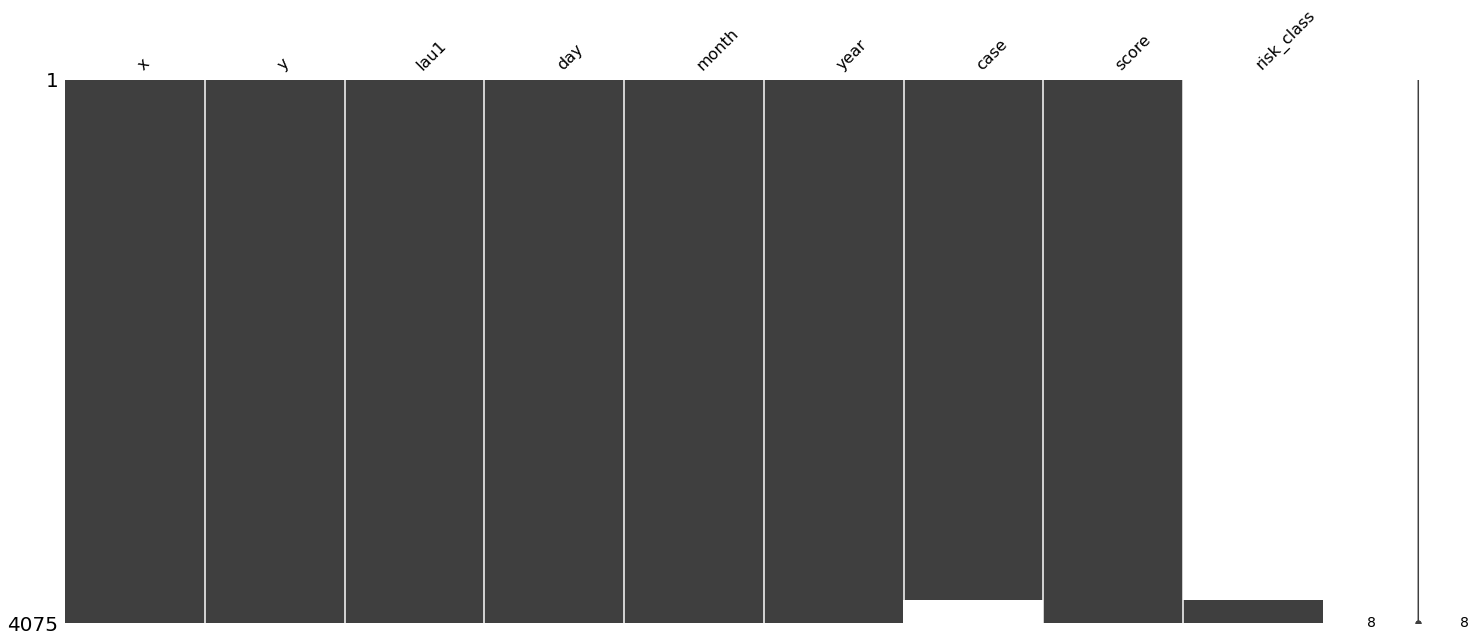

In [20]:
missingno.matrix(concated)

In [21]:
days = np.sort(concated.day.unique())
days

array([ 1, 16], dtype=int64)

In [22]:
months = np.sort(concated.month.unique())
months

array([ 5,  6,  7,  8,  9, 10], dtype=int64)

In [23]:
years = np.sort(concated.year.unique())
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023], dtype=int64)

In [24]:
df = concated[(concated['month'] >= 5) & (concated['month'] <= 8)].copy()

In [25]:
condition = df[(df['month'] == 8) & (df['day'] == 16)].index
df.drop(condition, inplace = True)
df

,x,y,lau1,day,month,year,case,score,risk_class
1,22.341069,39.610479,λαρισαιων,16,7,2012,0.0,0.994613,NaN
2,22.341069,39.610479,λαρισαιων,1,8,2012,0.0,0.991909,NaN
4,22.296112,39.762971,τυρναβου,16,7,2012,0.0,0.986388,NaN
6,22.296112,39.762971,τυρναβου,1,8,2012,0.0,0.983773,NaN
7,22.341069,39.610479,λαρισαιων,1,8,2020,1.0,0.983670,NaN
...,...,...,...,...,...,...,...,...,...
4070,21.428660,39.481420,πυλης,16,5,2023,NaN,0.011205,1.0
4071,23.457880,39.167700,σκιαθου,16,5,2023,NaN,0.007200,0.0
4072,23.998420,39.245850,αλοννησου,16,5,2023,NaN,0.004229,0.0
4073,23.078000,39.457740,ζαγορας μουρεσιου,16,5,2023,NaN,0.001159,0.0


In [26]:
bins_path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Bins_2023.csv'

bins = []

with open(bins_path, mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        bins.extend(map(float, row))

print(bins)

[0.0, 0.0079983711252831, 0.0857458244919643, 0.5105258673268654, 0.8201202051121793, 0.9298314119184128, 1.0]


In [27]:
df['risk_class'] = pd.cut(df['score'], bins=bins, labels=False, include_lowest=True)
df.head(10)

,x,y,lau1,day,month,year,case,score,risk_class
1,22.341069,39.610479,λαρισαιων,16,7,2012,0.0,0.994613,5
2,22.341069,39.610479,λαρισαιων,1,8,2012,0.0,0.991909,5
4,22.296112,39.762971,τυρναβου,16,7,2012,0.0,0.986388,5
6,22.296112,39.762971,τυρναβου,1,8,2012,0.0,0.983773,5
7,22.341069,39.610479,λαρισαιων,1,8,2020,1.0,0.983670,5
10,22.159516,39.951738,ελασσονας,16,7,2012,0.0,0.980985,5
11,22.510982,39.513901,κιλελερ,16,7,2012,0.0,0.978177,5
12,22.159516,39.951738,ελασσονας,1,8,2012,0.0,0.978119,5
13,22.510982,39.513901,κιλελερ,1,8,2012,0.0,0.977806,5
15,22.341069,39.610479,λαρισαιων,1,8,2015,0.0,0.975525,5


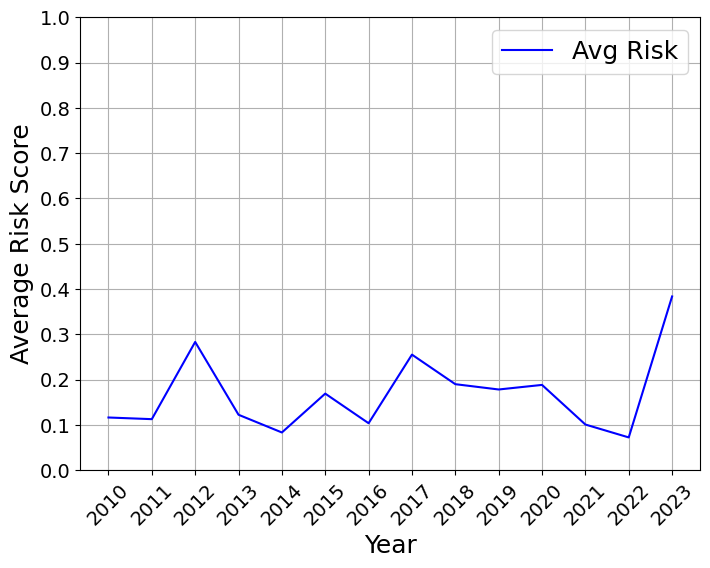

In [28]:
plot_trend_curve(df, plot_max = False, score_col = 'score', plot_cases=False, y_label='Average Risk Score')

In [30]:
risk_2022_over_7 = df[(df['year'] == 2022) & (df['risk_class'] >= 4)].copy()
risk_2022_over_7.reset_index(drop = True, inplace = True)
risk_2022_over_7

,x,y,lau1,day,month,year,case,score,risk_class
0,22.341069,39.610479,λαρισαιων,1,8,2022,0.0,0.87502,4


In [31]:
risk_2023_over_7 = df[(df['year'] == 2023) & (df['risk_class'] >= 4)].copy()
risk_2023_over_7.reset_index(drop = True, inplace = True)
risk_2023_over_7

,x,y,lau1,day,month,year,case,score,risk_class
0,22.34107,39.61048,λαρισαιων,1,8,2023,NaN,0.998770,5
1,22.29611,39.76297,τυρναβου,1,8,2023,NaN,0.998639,5
2,22.51098,39.51390,κιλελερ,1,8,2023,NaN,0.992481,5
3,22.02629,39.60300,φαρκαδονας,1,8,2023,NaN,0.984939,5
4,22.54288,39.85090,τεμπων,1,8,2023,NaN,0.970563,5
5,21.77435,39.61293,τρικκαιων,1,8,2023,NaN,0.925864,4
6,22.15952,39.95174,ελασσονας,1,8,2023,NaN,0.914812,4
7,22.09265,39.48079,παλαμα,1,8,2023,NaN,0.889549,4
8,22.43796,39.30328,φαρσαλων,1,8,2023,NaN,0.874878,4
9,22.29611,39.76297,τυρναβου,1,7,2023,NaN,0.989719,5
